In [6]:
import sys
import os
sys.path.append(os.path.abspath('..'))


import pandas as pd
import numpy as np

from data_preparation.data_processor import DataProcessor
from models import XGBoostParams

import xgboost as xgb
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL


In [7]:
XGBoostParams =  {
    "Municipal": {
        "colsample_bytree": 0.8,
        "gamma": 0,
        "learning_rate": 0.03,
        "max_depth": 4,
        "min_child_weight": 3,
        "n_estimators": 90,
        "reg_alpha": 0,
        "reg_lambda": 1
    },
    "Industrial": {
        "colsample_bytree": 0.8,
        "gamma": 0,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 5,
        "n_estimators": 70,
        "reg_alpha": 0,
        "reg_lambda": 0.5
    },
    "Organic": {
        "colsample_bytree": 0.8,
        "gamma": 0,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 5,
        "n_estimators": 110,
        "reg_alpha": 0.5,
        "reg_lambda": 1
    },
    "Construction": {
        "colsample_bytree": 0.8,
        "gamma": 0,
        "learning_rate": 0.09000000000000001,
        "max_depth": 3,
        "min_child_weight": 5,
        "n_estimators": 70,
        "reg_alpha": 0,
        "reg_lambda": 1
    },
    "Commercial": {
        "colsample_bytree": 1.0,
        "gamma": 0,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 3,
        "n_estimators": 70,
        "reg_alpha": 0.5,
        "reg_lambda": 1
    }
}

In [8]:
waste_data = pd.read_csv("../synthetic_waste_data.csv")

fetcher = DataProcessor(waste_data)

unique_waste = fetcher.waste_data['waste_type'].unique()
waste_dfs = {}

lags = [1,6]

for waste in unique_waste:
    prep_data_company = fetcher.agg_quantity(waste_type=waste, by_waste_type= True)
    # Perform seasonal decomposition on the entire data
    #stl = STL(prep_data_company['quantity_tons'], period=12)
    #res = stl.fit()
    #
    ## Extract the seasonal component for the entire data
    #seasonal = res.seasonal
    #
    ## Shift the seasonal component by one period
    #seasonal_shifted = seasonal.shift(-1)
    #
    ## Create a new feature based on the shifted seasonal component
    #prep_data_company['seasonal_shifted'] = seasonal_shifted
    waste_dfs[waste] = fetcher.create_xgboost_features(prep_data_company, lags=lags, lagged_features= True,lagged_ratios= False ,fourier_terms= False, interaction_terms= False)


for c in range(len(unique_waste)):
    waste = list(waste_dfs.keys())[c]
    print(f"Data shape for {waste}:")
    print(waste_dfs[waste].shape)

Data shape for Municipal:
(1090, 16)
Data shape for Industrial:
(1090, 16)
Data shape for Organic:
(1090, 16)
Data shape for Construction:
(1090, 16)
Data shape for Commercial:
(1090, 16)


In [9]:
waste_dfs["Municipal"]

,is_Fall,is_Spring,is_Summer,is_Winter,quantity_tons,is_weekend,is_holiday,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag_1,lag_6
date,,,,,,,,,,,,,,,,
2022-01-07,0.0,0.0,0.0,1.0,86.602150,0.0,0.0,4,1,1,2022,7,7,1,96.313774,16.381126
2022-01-08,0.0,0.0,0.0,1.0,57.887192,1.0,0.0,5,1,1,2022,8,8,1,86.602150,0.000000
2022-01-09,0.0,0.0,0.0,1.0,0.000000,1.0,0.0,6,1,1,2022,9,9,1,57.887192,230.263626
2022-01-10,0.0,0.0,0.0,1.0,87.551895,0.0,0.0,0,1,1,2022,10,10,2,0.000000,124.063835
2022-01-11,0.0,0.0,0.0,1.0,83.100616,0.0,0.0,1,1,1,2022,11,11,2,87.551895,74.480949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,0.0,0.0,0.0,1.0,232.099213,0.0,1.0,4,4,12,2024,362,27,52,330.068146,26.468199
2024-12-28,0.0,0.0,0.0,1.0,91.199692,1.0,1.0,5,4,12,2024,363,28,52,232.099213,12.783320
2024-12-29,0.0,0.0,0.0,1.0,6.269297,1.0,0.0,6,4,12,2024,364,29,52,91.199692,290.671234


<Figure size 1000x800 with 0 Axes>

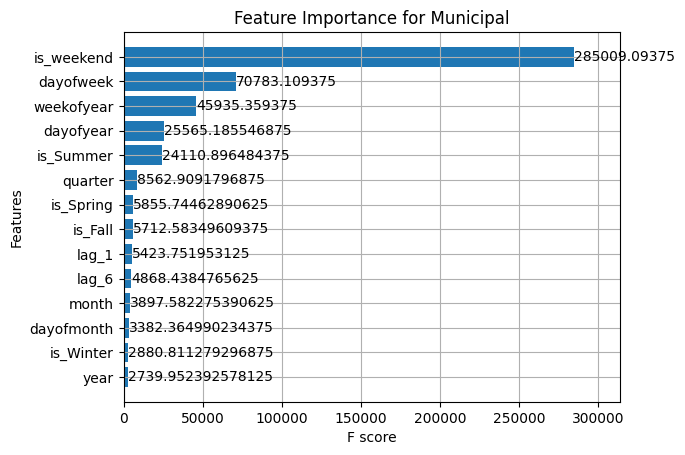

<Figure size 1000x800 with 0 Axes>

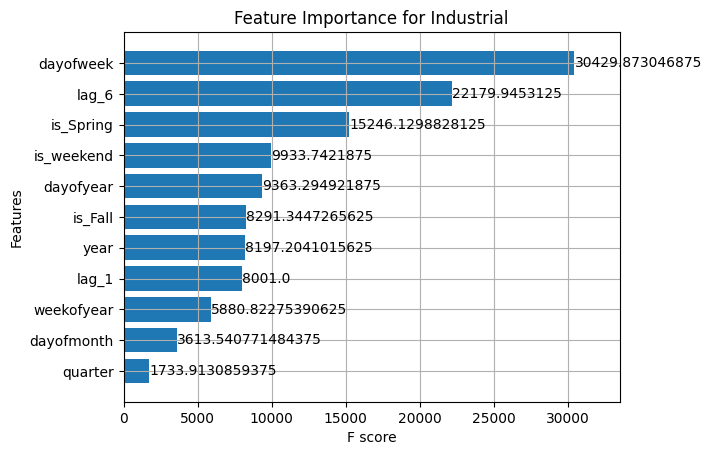

<Figure size 1000x800 with 0 Axes>

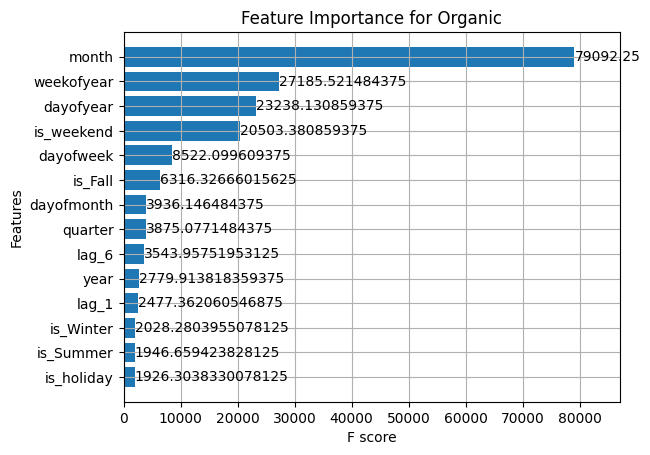

<Figure size 1000x800 with 0 Axes>

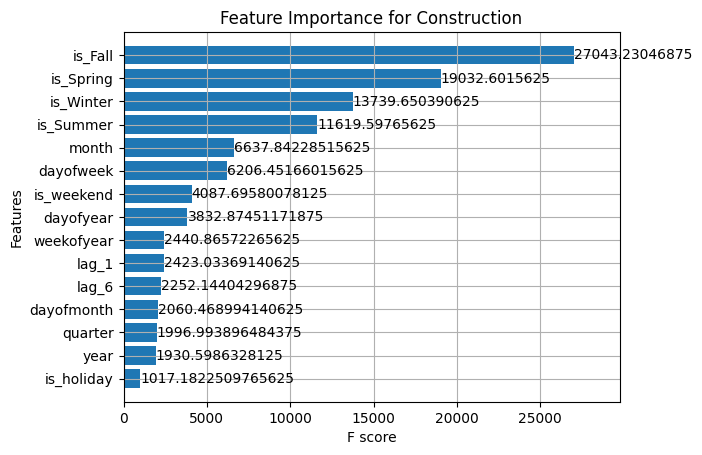

<Figure size 1000x800 with 0 Axes>

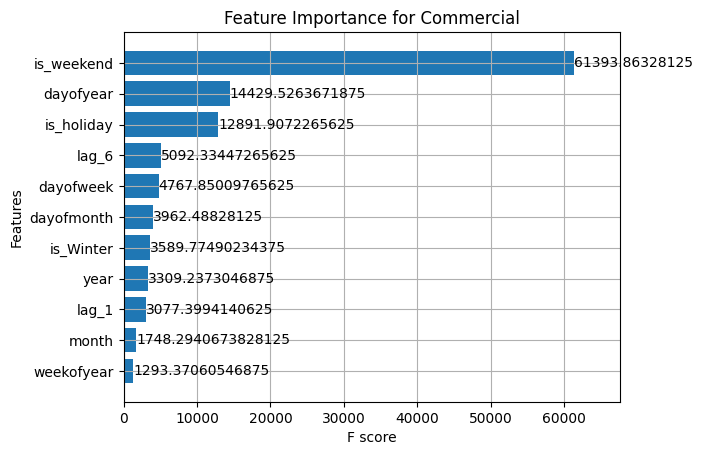

In [10]:
split_index = int(waste_dfs["Municipal"].shape[0] * 0.8)


waste_quantity_preds = {}

for waste, df in waste_dfs.items():

    X = df.drop(columns=['quantity_tons'])
    y = df['quantity_tons']

    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]
    
    # Get the best parameters for this company
    best_params = XGBoostParams[waste]
    
    
    # Create and train the model with best parameters
    best_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        **best_params  # Unpack the parameters
    )
    
    best_model.fit(X_train, y_train)

    y_pred = best_model.predict(X_test)
    waste_quantity_preds[waste] = y_pred

    # Plot feature importance
    plt.figure(figsize=(10, 8))
    xgb.plot_importance(best_model, max_num_features=20, height=0.8, importance_type="gain")
    plt.title(f"Feature Importance for {waste}")
    plt.show()

In [11]:
from sklearn.metrics import root_mean_squared_error

total_actual = np.sum(
    [waste_dfs[waste]['quantity_tons'].values[split_index:] for waste in waste_dfs],
    axis=0
)


total_predicted = np.sum(list(waste_quantity_preds.values()), axis=0)

print(f"RMSE:{root_mean_squared_error(total_actual, total_predicted)}")

for waste in unique_waste:
    actual = np.sum(
    [waste_dfs[waste]['quantity_tons'].values[split_index:]],
    axis=0)

    predicted = waste_quantity_preds[waste]

    print(f"RMSE for {waste}: {root_mean_squared_error(actual, predicted)}")


RMSE:97.75377655029297
RMSE for Municipal: 52.2230110168457
RMSE for Industrial: 41.801612854003906
RMSE for Organic: 35.666385650634766
RMSE for Construction: 30.992080688476562
RMSE for Commercial: 34.385887145996094


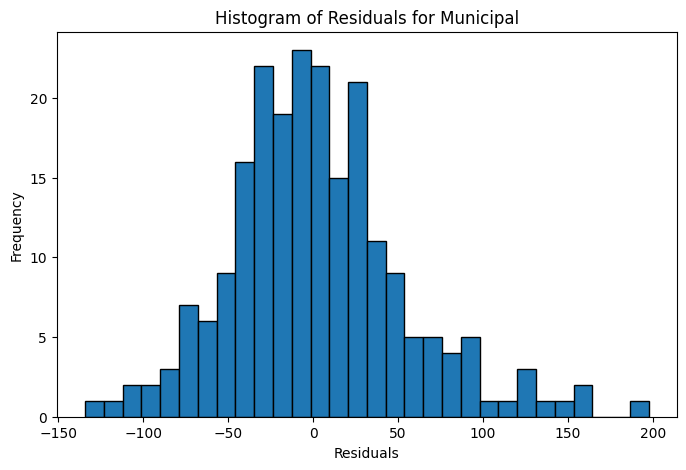

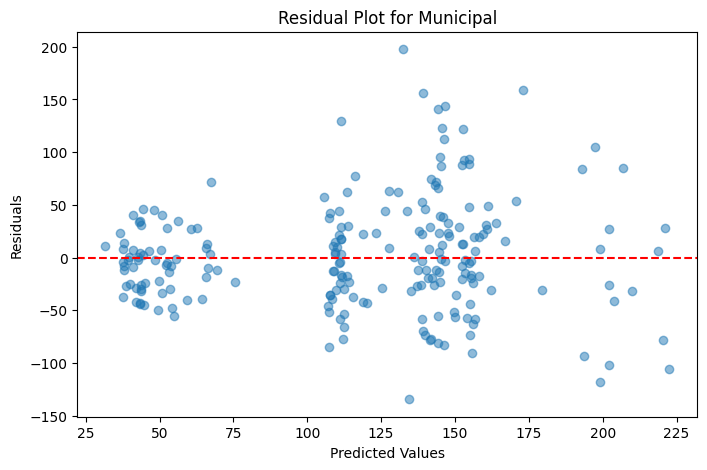

Municipal - Mean Residual: 2.46
Municipal - Standard Deviation: 52.16


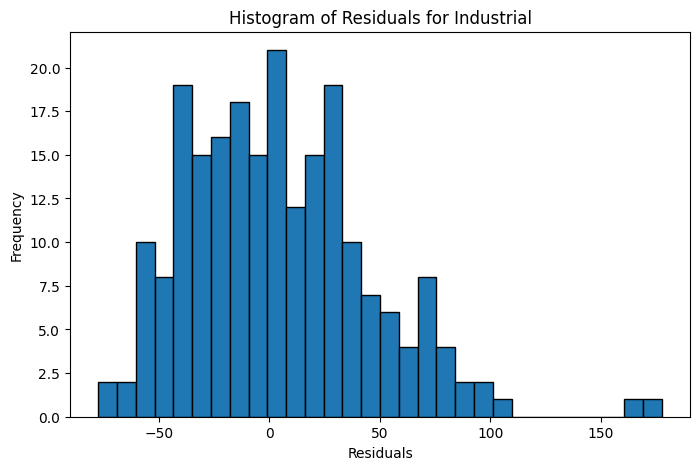

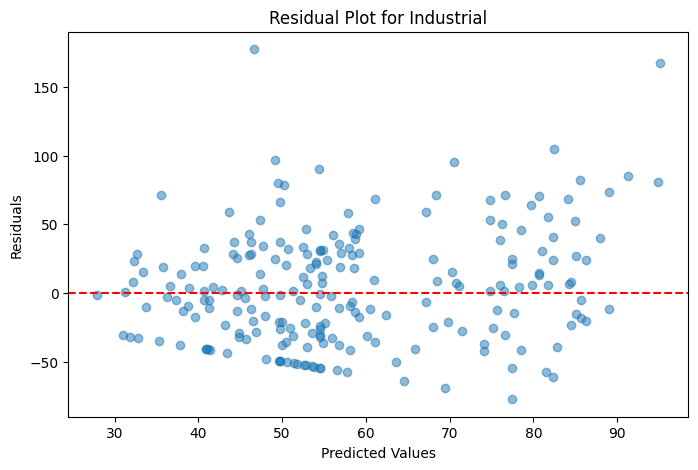

Industrial - Mean Residual: 4.33
Industrial - Standard Deviation: 41.58


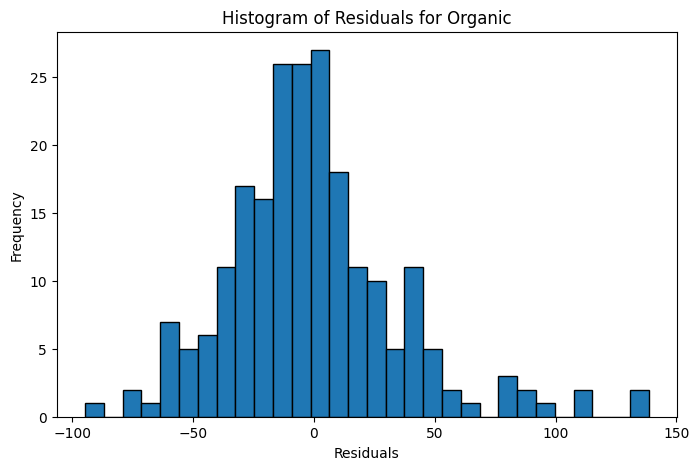

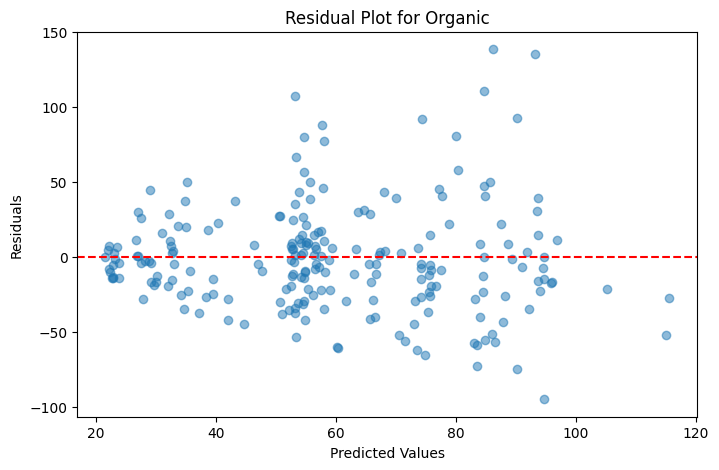

Organic - Mean Residual: -0.99
Organic - Standard Deviation: 35.65


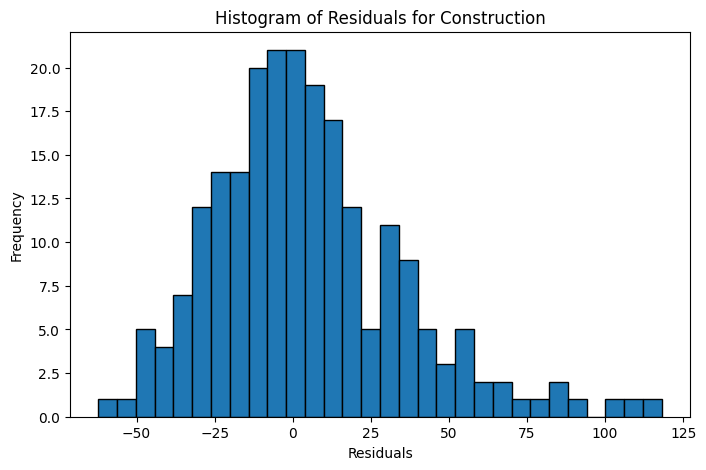

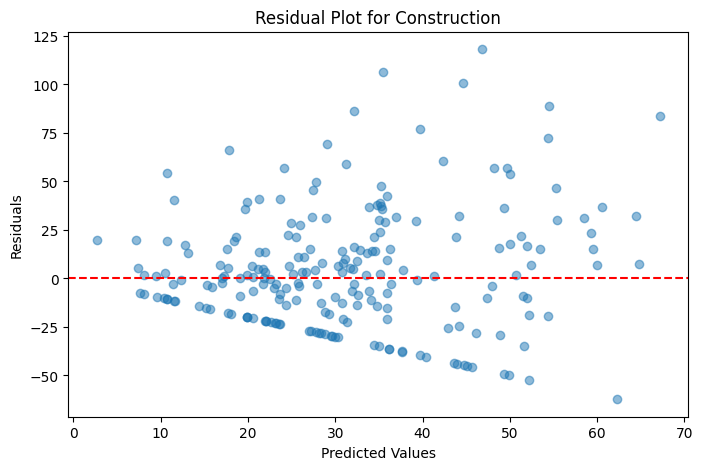

Construction - Mean Residual: 4.76
Construction - Standard Deviation: 30.62


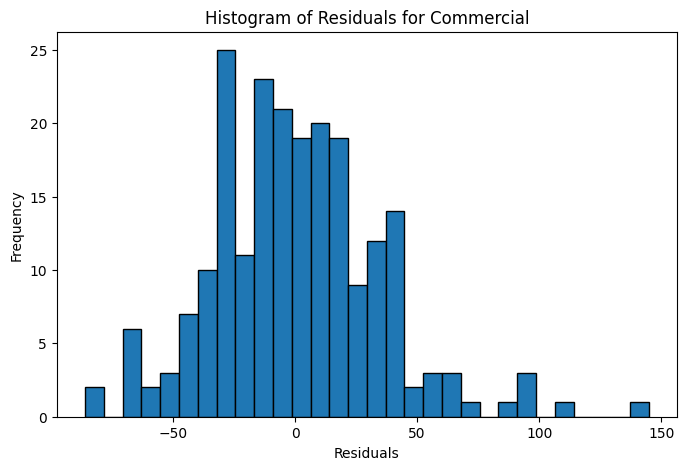

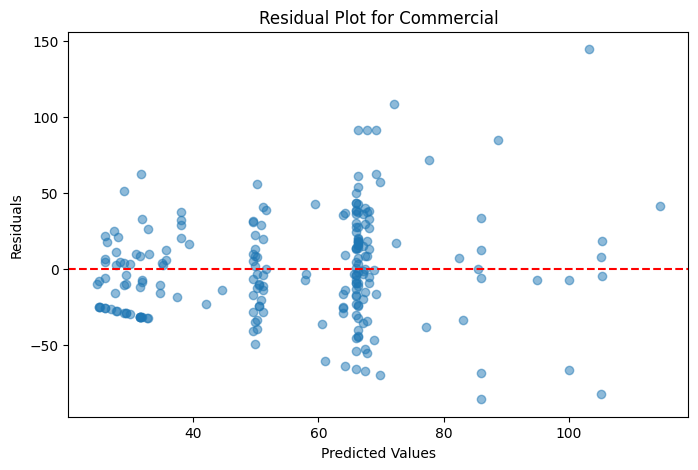

Commercial - Mean Residual: 0.52
Commercial - Standard Deviation: 34.38


In [13]:
# Assuming company_dfs is a dictionary with company names as keys
for waste in waste_dfs:
    # Calculate total actual values for the company
    total_actual = waste_dfs[waste]['quantity_tons'].values[split_index:]

    # Calculate total predicted values for the company
    total_predicted = waste_quantity_preds[waste]  # Assuming company_quantity_preds is a dict

    # Calculate residuals
    residuals = total_actual - total_predicted

    # Plot histogram of residuals
    plt.figure(figsize=(8, 5))
    plt.hist(residuals, bins=30, edgecolor="black")
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Residuals for {waste}")
    plt.show()

    # Plot residuals against predicted values
    plt.figure(figsize=(8, 5))
    plt.scatter(total_predicted, residuals, alpha=0.5)
    plt.axhline(y=0, color="red", linestyle="--")  # Zero-line for reference
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot for {waste}")
    plt.show()

    # Print mean and standard deviation of residuals
    print(f"{waste} - Mean Residual: {residuals.mean():.2f}")
    print(f"{waste} - Standard Deviation: {residuals.std():.2f}")


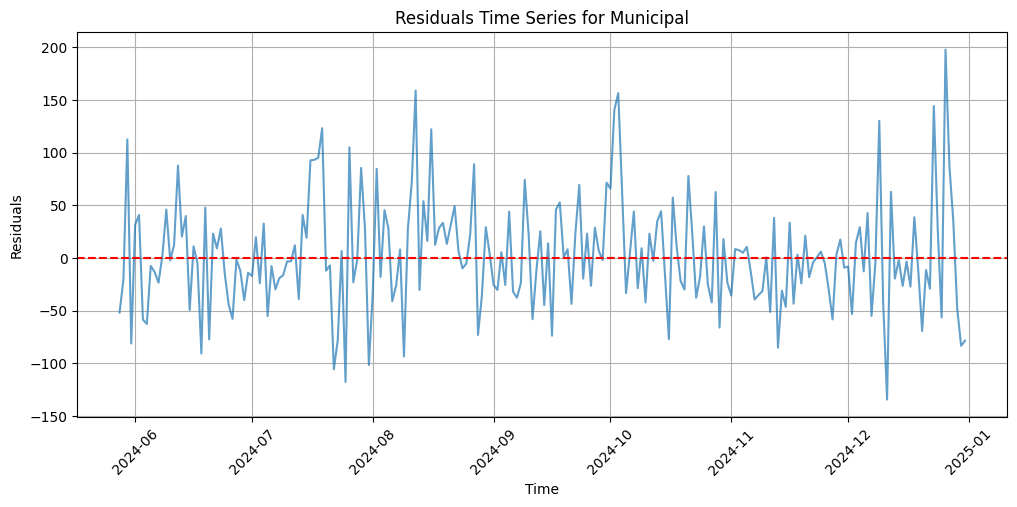

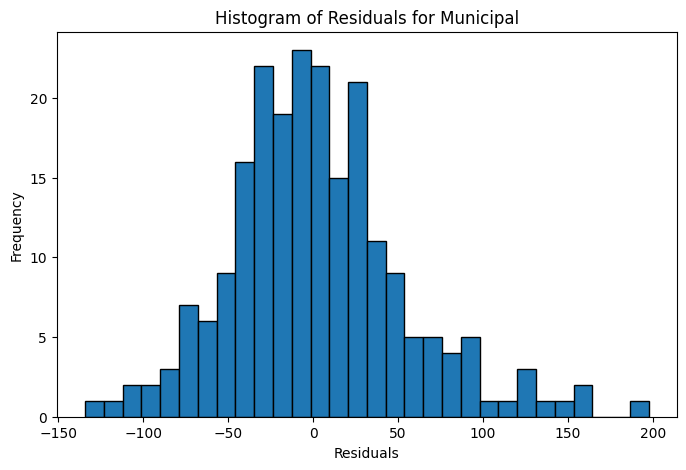

Municipal - Mean Residual: 2.46
Municipal - Standard Deviation: 52.16


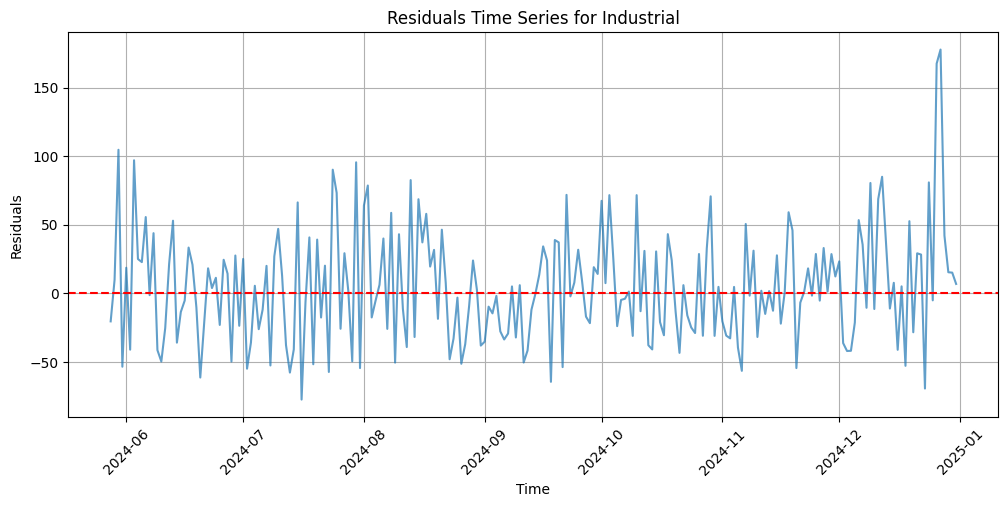

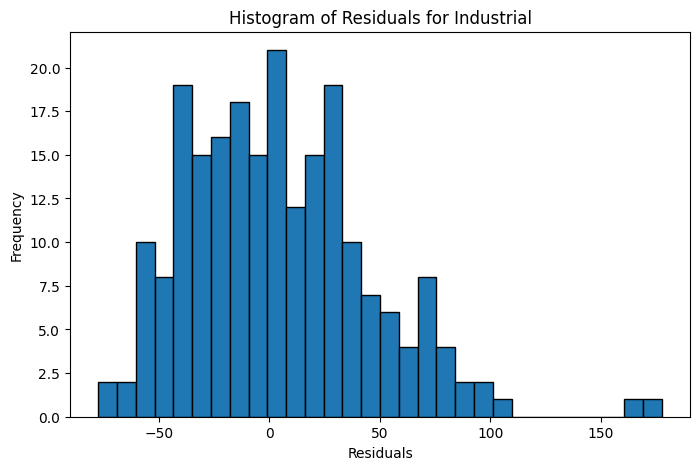

Industrial - Mean Residual: 4.33
Industrial - Standard Deviation: 41.58


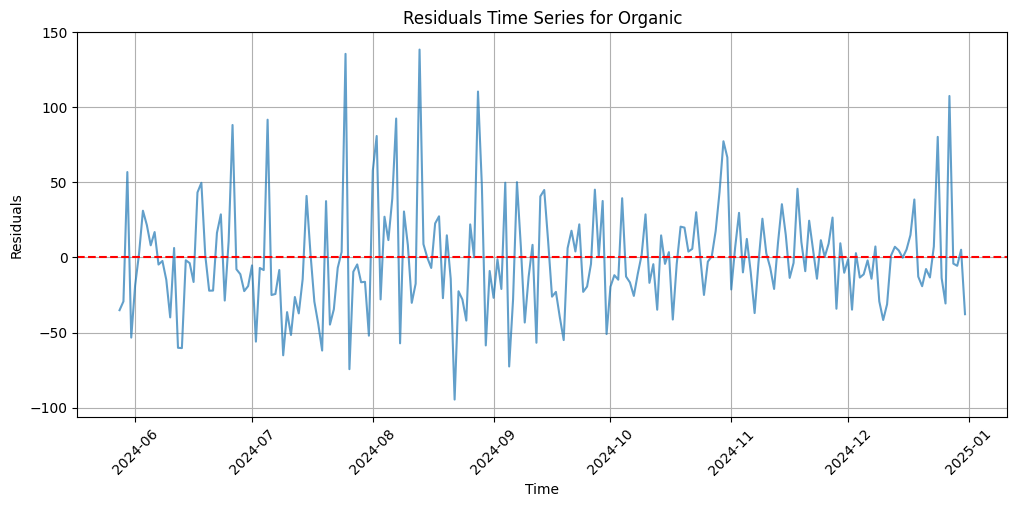

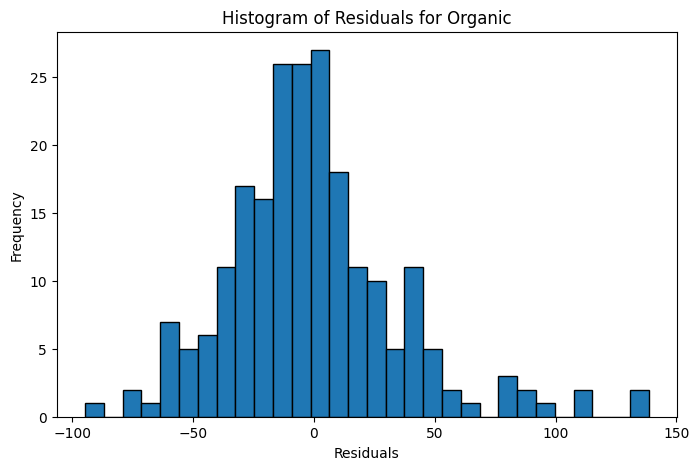

Organic - Mean Residual: -0.99
Organic - Standard Deviation: 35.65


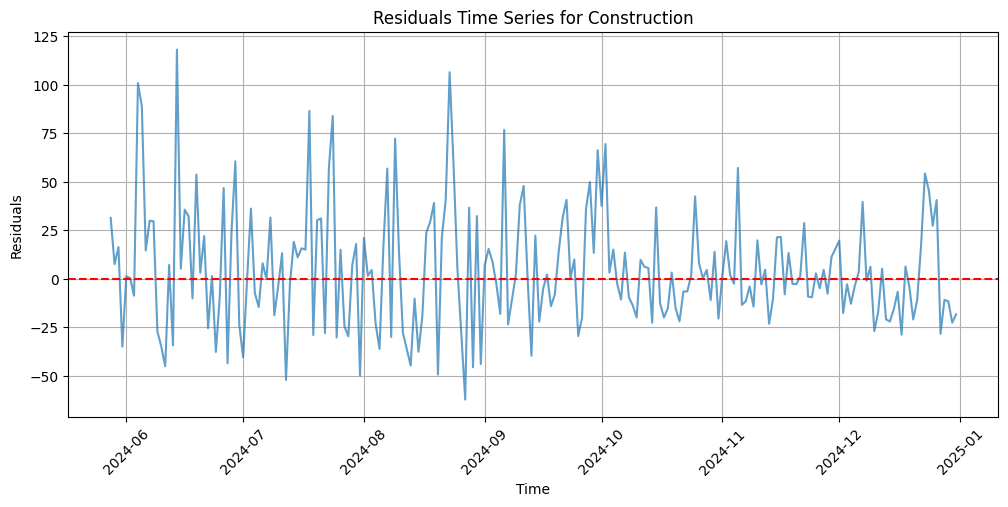

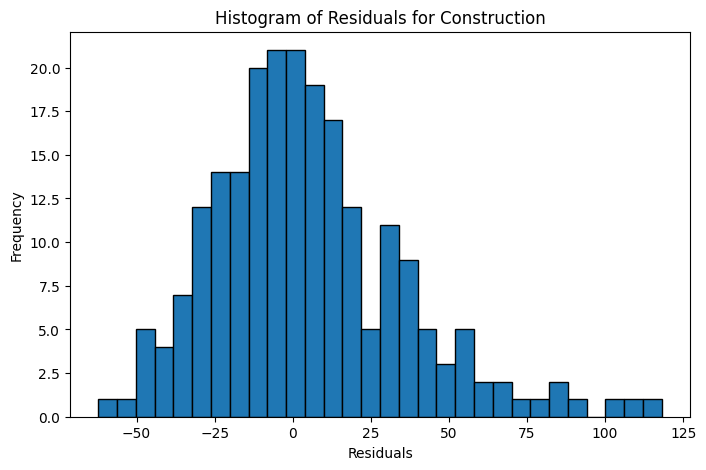

Construction - Mean Residual: 4.76
Construction - Standard Deviation: 30.62


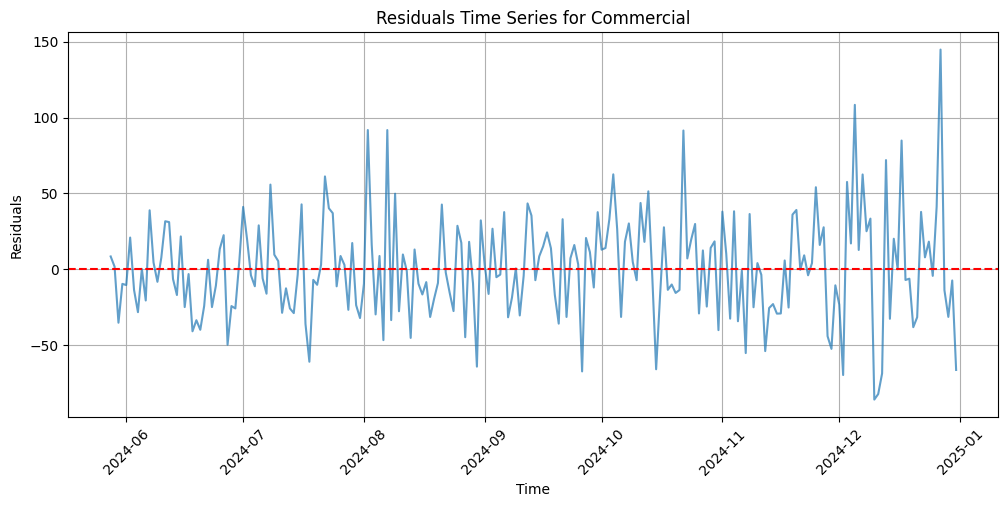

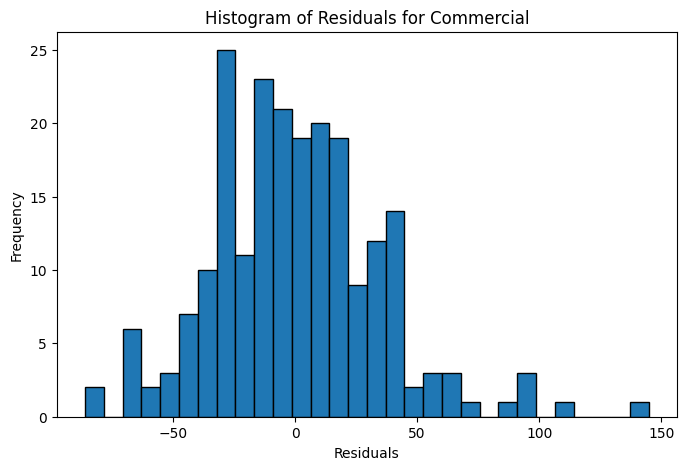

Commercial - Mean Residual: 0.52
Commercial - Standard Deviation: 34.38


In [15]:
# Assuming company_dfs is a dictionary with company names as keys
for waste in waste_dfs:
    # Calculate total actual values for the company
    total_actual = waste_dfs[waste]['quantity_tons'].values[split_index:]

    # Calculate total predicted values for the company
    total_predicted = waste_quantity_preds[waste]  # Assuming company_quantity_preds is a dict

    # Calculate residuals
    residuals = total_actual - total_predicted

    # Get the time index for the residuals
    time_index = waste_dfs[waste].index[split_index:]

    # Plot residuals as points over time
    plt.figure(figsize=(12, 5))
    plt.plot(time_index, residuals, alpha=0.7)
    plt.axhline(y=0, color="red", linestyle="--")  # Zero-line for reference
    plt.xlabel("Time")
    plt.ylabel("Residuals")
    plt.title(f"Residuals Time Series for {waste}")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

    # Plot histogram of residuals
    plt.figure(figsize=(8, 5))
    plt.hist(residuals, bins=30, edgecolor="black")
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Residuals for {waste}")
    plt.show()

    # Print mean and standard deviation of residuals
    print(f"{waste} - Mean Residual: {residuals.mean():.2f}")
    print(f"{waste} - Standard Deviation: {residuals.std():.2f}")